# Disease Vectors Analogical Reasoning

In this notebook, we show how to use our model to compute disease vectors.  quantify how related they are analogically. 

## Getting the relevant slice of our dataset

In [1]:
import os
import pandas as pd
EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_vector/vector_data/'
save_path = '/media/rohola/ssd_storage/primary_metadata/'

DISEASES_DICT = {'respiratory': [ 'COVID-19', 'influenza', 'lung adenocarcinoma'],
                'neurological': ['Alzheimer disease', 'Parkinson disease', 'glioblastoma'],
                'cardiometabolic': ['myocardial infarction', 'dilated cardiomyopathy', 'arrhythmogenic right ventricular cardiomyopathy']}

files = sorted(os.listdir(save_path))
df = pd.concat([pd.read_pickle(save_path+f) for f in files], ignore_index=True)

In [ ]:
# Get counts of cell types per disease
results=[];print(df.shape)
for d in sum(list(DISEASES_DICT.values()),[]):
    t=df[df['disease']==d].value_counts(['cell_type','tissue_general']).reset_index().head(3)
    t.columns=['cell_type','tissue_general',d];results.append(t)
display(pd.concat(results,axis=1))

(35750000, 27)


,cell_type,tissue_general,COVID-19,cell_type,tissue_general,influenza,cell_type,tissue_general,lung adenocarcinoma,cell_type,...,glioblastoma,cell_type,tissue_general,myocardial infarction,cell_type,tissue_general,dilated cardiomyopathy,cell_type,tissue_general,arrhythmogenic right ventricular cardiomyopathy
0,B cell,blood,500239,classical monocyte,blood,11473,"CD4-positive, alpha-beta T cell",lung,125029,neuron,...,409290,cardiac muscle myoblast,heart,50330,cardiac muscle cell,heart,149631,fibroblast of cardiac tissue,heart,25113
1,"CD8-positive, alpha-beta T cell",blood,484430,"CD4-positive, alpha-beta T cell",blood,5369,"CD8-positive, alpha-beta T cell",lung,99858,microglial cell,...,275761,fibroblast of cardiac tissue,heart,43717,mural cell,heart,97754,cardiac muscle cell,heart,24592
2,"CD4-positive, alpha-beta T cell",blood,371921,"CD8-positive, alpha-beta T cell",blood,3956,alveolar macrophage,lung,68185,T cell,...,205025,cardiac endothelial cell,heart,31904,endothelial cell,heart,83890,mural cell,heart,22561


In [7]:
DISEASES_DICT = {
                'respiratory': [ 'COVID-19', 'influenza', 'lung adenocarcinoma'],
                'neurological': ['Alzheimer disease', 'Parkinson disease', 'glioblastoma'],
                'cardiac': ['myocardial infarction', 'dilated cardiomyopathy', 'arrhythmogenic right ventricular cardiomyopathy']
                }

CELL_TYPE_DICT = {
                'COVID-19': ['CD8-positive, alpha-beta T cell', 'CD4-positive, alpha-beta T cell', 'B cell', 'classical monocyte'],
                  'influenza': ['CD8-positive, alpha-beta T cell', 'CD4-positive, alpha-beta T cell', 'classical monocyte'],
                  'lung adenocarcinoma': ['CD8-positive, alpha-beta T cell', 'CD4-positive, alpha-beta T cell', 'B cell'],
                  'Alzheimer disease': ['neuron', 'microglial cell'],
                  'Parkinson disease':['oligodendrocyte', 'neuron', 'microglial cell', 'astrocyte', 'endothelial cell'],
                  'glioblastoma':['malignant cell', 'microglial cell', 'endothelial cell', 'oligodendrocyte', 'monocyte'],
                  'myocardial infarction':['cardiac muscle myoblast', 'fibroblast of cardiac tissue', 'cardiac endothelial cell'],
                  'dilated cardiomyopathy':['cardiac muscle cell', 'fibroblast of cardiac tissue', 'endothelial cell'],
                  'arrhythmogenic right ventricular cardiomyopathy' :['fibroblast of cardiac tissue', 'cardiac muscle cell', 'endothelial cell']
                  }

TISSUE_DICT = {
                'COVID-19': ['blood'],
                  'influenza': ['blood'],
                  'lung adenocarcinoma': ['lung'],
                  'Alzheimer disease': ['brain'],
                  'Parkinson disease':['brain'],
                  'glioblastoma':['brain'],
                  'myocardial infarction':['heart'],
                  'dilated cardiomyopathy':['heart'],
                  'arrhythmogenic right ventricular cardiomyopathy' :['heart']
                  }

The rest is executed in the script get_cells_for_vectors.py

## Exploration

In [16]:
SAVE = False
#SAVE_SHOW = True

In [17]:
import scanpy as sc, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cosine
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
from matplotlib.lines import Line2D
from scipy.spatial.distance import pdist
def plot_umap(df, disease_label, labels, palette_dict, reduction='umap', endotype_matching=False, figure_size=(8,6), marker_size=40, save_path=None, alpha=0.8, lw=0.1, fontsize=12, eps=5.0, min_samples=50 ):

    if endotype_matching:
        print('Cluster removal filtration epsilon', eps, "min and max", df[['UMAP1','UMAP2']].min().tolist(), df[['UMAP1','UMAP2']].max().tolist())
        keep_indices = []
        for (cell_type, disease), g in df.groupby(['cell_type','disease']):
            lab = DBSCAN(eps=eps, min_samples=min_samples).fit(g[['UMAP1','UMAP2']]).labels_
            s = pd.Series(lab, index=g.index)
            if (s!=-1).any():
                main = s[s!=-1].value_counts().idxmax()
                keep_indices.append(s.index[s==main])
        if len(keep_indices)==0:
            return
        keep_indices = np.concatenate([i.values for i in keep_indices])
        df_plot = df.loc[keep_indices]
    else: df_plot = df

    fig, ax = plt.subplots(figsize=figure_size, dpi=300 if SAVE else 100)
    hue_vals = labels if isinstance(labels, str) else labels.loc[df_plot.index]
    sns.scatterplot(data=df_plot, x='UMAP1', y='UMAP2', hue=hue_vals, palette=palette_dict, s=marker_size, alpha=alpha, ax=ax, linewidth=lw, zorder=1)# edgecolor='k'
    ax.set_axisbelow(True)

    disease_vectors = []
    disease_vectors_linear = []
    for cell_type in df_plot['cell_type'].unique():
        normal_cells = df_plot[(df_plot['disease'] == 'normal') & (df_plot['cell_type'] == cell_type)]
        disease_cells = df_plot[(df_plot['disease'] == disease_label) & (df_plot['cell_type'] == cell_type)]
        if len(normal_cells) > 0 and len(disease_cells) > 0:
            normal_centroid_emb = np.array(normal_cells['embedding'].tolist()).mean(axis=0) if 'embedding' in df_plot.columns else None
            disease_centroid_emb = np.array(disease_cells['embedding'].tolist()).mean(axis=0) if 'embedding' in df_plot.columns else None
            if normal_centroid_emb is not None and disease_centroid_emb is not None:
                disease_vectors.append(disease_centroid_emb - normal_centroid_emb)
            normal_centroid = normal_cells[['UMAP1','UMAP2']].mean().values
            disease_centroid = disease_cells[['UMAP1','UMAP2']].mean().values
            disease_vectors_linear.append(disease_centroid - normal_centroid)
            ax.quiver(normal_centroid[0], normal_centroid[1], disease_centroid[0]-normal_centroid[0], disease_centroid[1]-normal_centroid[1], angles='xy', scale_units='xy', scale=1, width=0.008, headwidth=4, headlength=6, headaxislength=4, linewidth=.01, color='black')

    arrow_proxy = FancyArrowPatch((0, 0), (1, 0), arrowstyle='-|>', mutation_scale=15, color='black', linewidth=1)
    def make_legend_quiver(legend, orig_handle, xdescent, ydescent, width, height, fontsize):
        return FancyArrowPatch((0, height*0.5), (width, height*0.5), arrowstyle='-|>', mutation_scale=fontsize, color='black', linewidth=1)

    def cosine_sim(a, b): return 1 - cosine(a, b)
    r = cosine_sim(disease_vectors[0], disease_vectors[1]) if len(disease_vectors) == 2 else 0

    handles, legend_labels_ = ax.get_legend_handles_labels()
    handles.append(arrow_proxy)
    legend_labels_.append(f"Disease Vectors ($\\rho$={r:.2f})")
    palette_order = list(palette_dict.keys())
    order = sorted(range(len(handles)-1), key=lambda i: palette_order.index(legend_labels_[i]) if legend_labels_[i] in palette_order else len(palette_order)) + [len(handles)-1]
    legend_labels_ = [' '.join([word.capitalize() for word in x.replace(' disease', '').split(' ')]) for x in legend_labels_]
    legend_labels_ = [' '.join(label.split('_'))
                      .replace('Cd4 positive alpha beta t cell', 'Helper T cell').replace('Cd8 positive alpha beta t cell', 'Cytotoxic T cell'
                    ).replace("Classical monocyte", "Monocyte").replace('Fibroblast of cardiac tissue', 'Cardiac Fibroblast'
                ).replace('Cardiac muscle myoblast', 'Cardiac Myoblast').replace('Cardiac endothelial cell', 'Endothelial cell') for label in legend_labels_]
    
    legend = ax.legend(np.array(handles)[order].tolist(), np.array(legend_labels_)[order].tolist(), frameon=True, loc='best', borderaxespad=1, edgecolor='lightgrey', framealpha=0.9, handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_legend_quiver)}, fontsize=fontsize-4)
    for handle in legend.legendHandles:
        if hasattr(handle, "set_markersize"):
            handle.set_markersize(6) 
            handle.set_alpha(1)

    ax.set_xticklabels([]); ax.set_yticklabels([])
    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.2, color='k', zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['bottom', 'left']].set_linewidth(2)
    ax.set_xlabel(f'{reduction.upper()}1', fontsize=fontsize+2)
    ax.set_ylabel(f'{reduction.upper()}2', fontsize=fontsize+2)
    surround_border = 3
    ax.set_xlim(df_plot['UMAP1'].quantile(.01)-surround_border, df_plot['UMAP1'].quantile(.99)+surround_border)
    ax.set_ylim(df_plot['UMAP2'].quantile(.01)-surround_border, df_plot['UMAP2'].quantile(.99)+surround_border)

    # quiver phase space
    if disease_vectors_linear:
        v=np.mean(disease_vectors_linear,axis=0);v=v/np.linalg.norm(v)
        x_min,x_max=df_plot['UMAP1'].min()-surround_border,df_plot['UMAP1'].max()+surround_border
        y_min,y_max=df_plot['UMAP2'].min()-surround_border,df_plot['UMAP2'].max()+surround_border
        n=15;xg=np.linspace(x_min,x_max,n);yg=np.linspace(y_min,y_max,n);X,Y=np.meshgrid(xg,yg)
        ax.quiver(X,Y,np.full_like(X,v[0]),np.full_like(Y,v[1]),color='k',alpha=0.1,
                scale_units='xy',scale=1.5,width=0.003,headwidth=3,headlength=5,
                headaxislength=4,zorder=-100)
    
    plt.tight_layout()
    if SAVE: plt.savefig(f"../figures/figure4/{disease_label}_{'_'.join(df_plot['cell_type'].unique().tolist())}.svg", dpi=300, transparent=True)
    #plt.savefig(f"../figures/figure4/show/{disease_label}_{'_'.join(df_plot['cell_type'].unique().tolist())}.png", dpi=300, transparent=False)
    plt.show()
    return ax

COVID-19


,disease,cell_type,0
0,covid_19,cd4_positive_alpha_beta_t_cell,2000
1,covid_19,cd8_positive_alpha_beta_t_cell,2000
2,normal,cd4_positive_alpha_beta_t_cell,2000
3,normal,cd8_positive_alpha_beta_t_cell,2000


Cluster removal filtration epsilon 3 min and max [-9.91226610055848, -9.011347810218833] [9.218052976175944, 11.038394041626253]


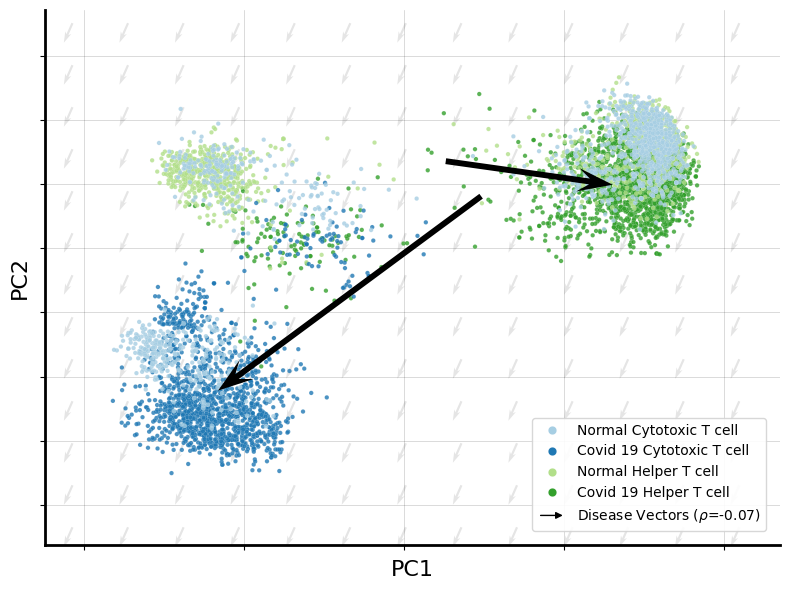

In [18]:
from sklearn.decomposition import PCA
import scanpy as sc, pandas as pd, numpy as np
import itertools
import sys
sys.path.append('../../../')
from polygene.model.model import load_trained_model
from polygene.data_utils.tokenization import normalise_str
m, tok = load_trained_model("../../../runs/gesam_polygene_run_4/")

DISEASES_DICT = {'respiratory': [ 'COVID-19', 'influenza', 'lung adenocarcinoma'],
                'neurological': ['Alzheimer disease', 'Parkinson disease', 'glioblastoma'],
                'cardiometabolic': ['myocardial infarction', 'dilated cardiomyopathy', 'arrhythmogenic right ventricular cardiomyopathy']}
EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_vector/vector_data/'
phenotypic_types = tok.phenotypic_types
diseases = sum(list(DISEASES_DICT.values()), [])

for disease in diseases[:1]: 
    if disease == 'normal': continue
    print(disease)
    embeddings = pd.read_pickle(EMBEDDINGS_DIR + disease + "_embeddings.pkl")
    df = pd.DataFrame({'embedding': embeddings[0].tolist(), 'y_pred': embeddings[1].tolist()}
                   | {phenotypic_types[idx]:embeddings[2][:, idx] for idx in range(len(phenotypic_types))})
    df[['disease', 'cell_type']] = df[['disease', 'cell_type']].applymap(lambda x: x[1:-1])
    #df = df[df['sex']=='[female]']
    df[['UMAP1', 'UMAP2']] = PCA(2).fit_transform(np.array(df['embedding'].tolist())).tolist()
    disease_cell_types = df['cell_type'].unique().tolist()
    disease = normalise_str(disease)[1:-1]
    for cell_type_pair in itertools.combinations(disease_cell_types, 2):
            ds = df[(df['disease'].isin([disease, 'normal'])) & (df['cell_type'].isin(cell_type_pair))]
            labels = ds.apply(lambda x: f"{x['disease']} {x['cell_type']}", axis=1)
            display(ds.value_counts(['disease', 'cell_type']).reset_index())
            palette_dict = {f"{cond} {c}": sns.color_palette('Paired', 30)[2*i + j]
                            for i, c in enumerate(cell_type_pair) for j, cond in enumerate(["normal", disease])}
            ax = plot_umap(ds, disease, labels, palette_dict, figure_size=(8, 6), reduction="pc", fontsize=14, endotype_matching=True, marker_size=10, alpha=0.8,
                       min_samples=5,eps=3)
            break

Next we quantify how similar these disease vectors are. The implications of a disease vector a single translation for disease across tissues could lead to understanding the representations of tissues in other diseases. 

We can also compute the instrinsic nature of the vector with a cosine construction We denote $A$ Alzheimer's, $P$ Parkinson's, $O$ Oligodendrocytes, $M$ Microglial Cells. Missing $AO$ disease vector, can we construct a projection based disease vector. $$AO = cos(AM, PM)PO + O$$

The exact details can be found in get_disease_vectors.py

In [19]:
import matplotlib.pyplot as plt, seaborn as sns, numpy as np, pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_vector/vector_data/'
results = pd.read_pickle(EMBEDDINGS_DIR + "disease_vector_results.pkl")
similarity_matrices = pd.read_pickle( EMBEDDINGS_DIR + "disease_vector_similarity_matrices.pkl")

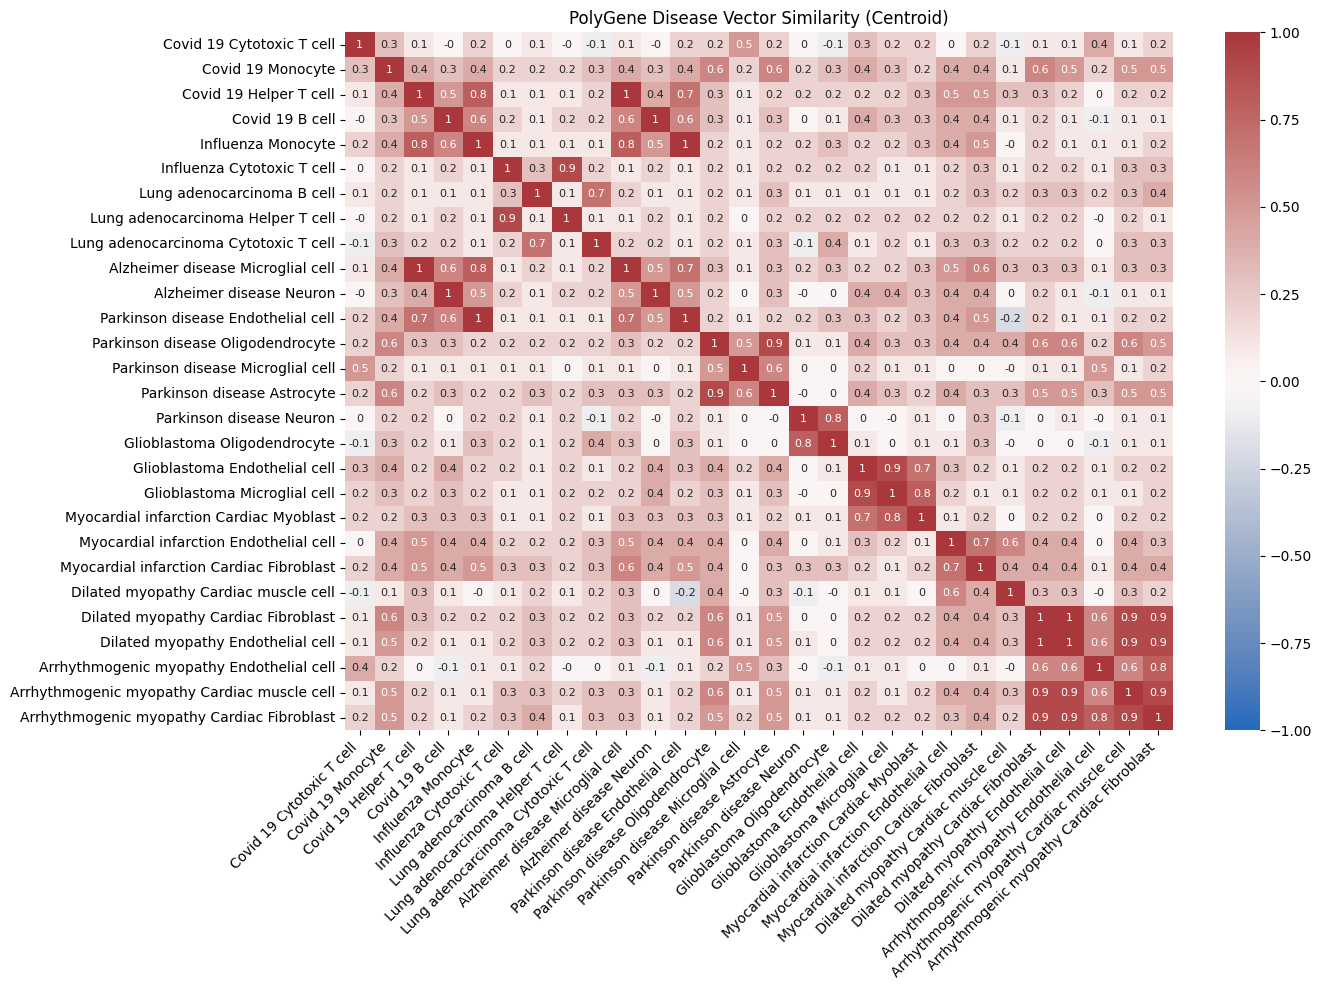

In [21]:
SAVE = False
fontsize=10
palette = "RdYlBu_r" # "vlag"
palette = "magma"
palette = "vlag"
round_digits = 1
round_technique =  "trun" # or round
dv = pd.DataFrame(results)
for vector_type in ['centroid']:#, 'raw_centroid', 'vectors' , 'raw_vectors']:
    matrix = similarity_matrices[vector_type]
    fig, ax = plt.subplots(1,1, figsize=(14,10), dpi= 300 if SAVE else 100)

    labels = [' '.join([word.capitalize() for word in x.replace(' disease', '').split(' ')]) for x in dv.columns]
    labels = [' '.join(label.split('_'))
                      .replace('Cd4 positive alpha beta t cell', 'Helper T cell').replace('Cd8 positive alpha beta t cell', 'Cytotoxic T cell'
                    ).replace("Classical monocyte", "Monocyte").replace('Fibroblast of cardiac tissue', 'Cardiac Fibroblast'
                ).replace('Cardiac muscle myoblast', 'Cardiac Myoblast').replace('Cardiac endothelial cell', 'Endothelial cell'
                    ).replace('Arrhythmogenic right ventricular', 'Arrhythmogenic').replace('cardiomyopathy', 'myopathy') for label in labels]
    

    vmin, vmax, center = (-1, 1, 0) if "centroid" in vector_type else (-0.5, 0.5, 0)
    if round_technique == "trunc": matrix = matrix.applymap(lambda x: int(x * 10**round_digits) / (10**round_digits))
    sns.heatmap(matrix.round(round_digits), annot=True, cmap=palette, center=center, vmin=vmin, vmax=vmax,
                 xticklabels=labels, yticklabels=labels, annot_kws={"size": fontsize-2},ax=ax)

    title = "PolyGene Disease Vector Similarity" if not "raw" in vector_type else "scRNA Disease Vector Similarity"
    title += " (Centroid)" if "centroid" in vector_type else " (Population)"
    plt.title(title, fontsize=fontsize+2)
    plt.xticks(rotation=45, ha="right", fontsize=fontsize)
    plt.yticks(rotation=0, fontsize=fontsize)
    plt.tight_layout()
    if SAVE: plt.savefig(f'../figures/figure4/{vector_type}_heatmap.svg', dpi=300, transparent=True)
    #if SAVE: plt.savefig(f'../figures/figure4/show/{vector_type}_heatmap.png', dpi=300, transparent=False)
    plt.show()

Next we explore the euclidean geometrical properties of this latent space

LEFT TO DO Attribution Analysis. show open targets benchmark in faithfulness plots. disease vector IG. do pruning but for each input

In [22]:
from sklearn.decomposition import PCA
import scanpy as sc, pandas as pd, numpy as np
import itertools
import sys
from tqdm import tqdm
sys.path.append('../../../')
from polygene.model.model import load_trained_model
from polygene.data_utils.tokenization import normalise_str
m, tok = load_trained_model("../../../runs/gesam_polygene_run_4/")
phenotypic_types = tok.phenotypic_types

DISEASES_DICT = {'respiratory': ['COVID-19','influenza','lung adenocarcinoma'],
                 'neurological': ['Alzheimer disease','Parkinson disease','glioblastoma'],
                 'cardiometabolic': ['myocardial infarction','dilated cardiomyopathy','arrhythmogenic right ventricular cardiomyopathy']}
EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_vector/vector_data/'

from scipy.spatial.distance import cosine

def parallelogram_score(A,B,C,D):
    u,u_p=B-A,D-C
    v,v_p=D-A,B-C
    s1,s2=cosine(u,u_p),cosine(v,v_p)
    return np.sqrt(np.clip((1 - s1) * (1 - s2), 0, 1))

def planarity_score(p1,p2,p3,q,eps=1e-12):
    u,v,w=p2-p1,p3-p1,q-p1
    U=np.stack([u,v],axis=1)
    coef,*_=np.linalg.lstsq(U,w,rcond=None)
    r=w-U@coef
    d=np.linalg.norm(r)
    s=max(np.linalg.norm(u),np.linalg.norm(v),eps)
    return 1/(1+d/s)

diseases=sum(list(DISEASES_DICT.values()), [])

cell_count=1000
cell_count_vectors=100
iterations=100

results_tmp={}
for disease in tqdm(diseases, desc="Disease Vectors"):
    if disease=='normal': continue
    embeddings=pd.read_pickle(EMBEDDINGS_DIR+disease+"_embeddings.pkl")
    df=pd.DataFrame(
        {'embedding':embeddings[0].tolist()}
        |{phenotypic_types[idx]:embeddings[2][:,idx] for idx in range(len(phenotypic_types))}
    )
    df[['disease','cell_type']]=df[['disease','cell_type']].applymap(lambda x: x[1:-1])
    disease_norm=normalise_str(disease)[1:-1]
    for _ in tqdm(range(iterations), desc="Bootstrap", leave=False):
        df_s=df.sample(cell_count, replace=True)
        disease_vectors={}
        for cell_type in df_s['cell_type'].unique():
            cell_group=df_s[df_s['cell_type']==cell_type]
            if "normal" not in cell_group['disease'].values or disease_norm not in cell_group['disease'].values: continue
            normal_embeddings=np.array(cell_group[cell_group['disease']=='normal']['embedding'].tolist())
            disease_embeddings=np.array(cell_group[cell_group['disease']==disease_norm]['embedding'].tolist())
            if len(normal_embeddings)==0 or len(disease_embeddings)==0: continue
            disease_vectors[f"{disease_norm} {cell_type}"]=disease_embeddings[:cell_count_vectors].mean(0)
            disease_vectors[f"normal {cell_type}"]=normal_embeddings[:cell_count_vectors].mean(0)
        valid_cell_types=sorted({k.split(' ',1)[1] for k in disease_vectors.keys() if k.startswith('normal ') and f"{disease_norm} {k.split(' ',1)[1]}" in disease_vectors})
        for cell1,cell2 in itertools.combinations(valid_cell_types, r=2):
            A=disease_vectors[f"{disease_norm} {cell1}"]
            B=disease_vectors[f"normal {cell1}"]
            C=disease_vectors[f"{disease_norm} {cell2}"]
            D=disease_vectors[f"normal {cell2}"]
            p=parallelogram_score(A,B,C,D)
            q=planarity_score(A,B,C,D)
            key=(disease_norm,cell1,cell2)
            if key not in results_tmp: results_tmp[key]={'parallelogram':[],'planarity':[]}
            results_tmp[key]['parallelogram'].append(p)
            results_tmp[key]['planarity'].append(q)

results={}
for key,vals in results_tmp.items():
    p=np.array(vals['parallelogram']); q=np.array(vals['planarity'])
    p_ci=np.percentile(p,[2.5,97.5]); q_ci=np.percentile(q,[2.5,97.5])
    results[key]={
        'parallelogram':{'mean':float(p.mean()),'ci_low':float(p_ci[0]),'ci_high':float(p_ci[1])},
        'planarity':{'mean':float(q.mean()),'ci_low':float(q_ci[0]),'ci_high':float(q_ci[1])}
    }
# 15s to run

Disease Vectors: 100%|██████████| 9/9 [00:09<00:00,  1.04s/it]


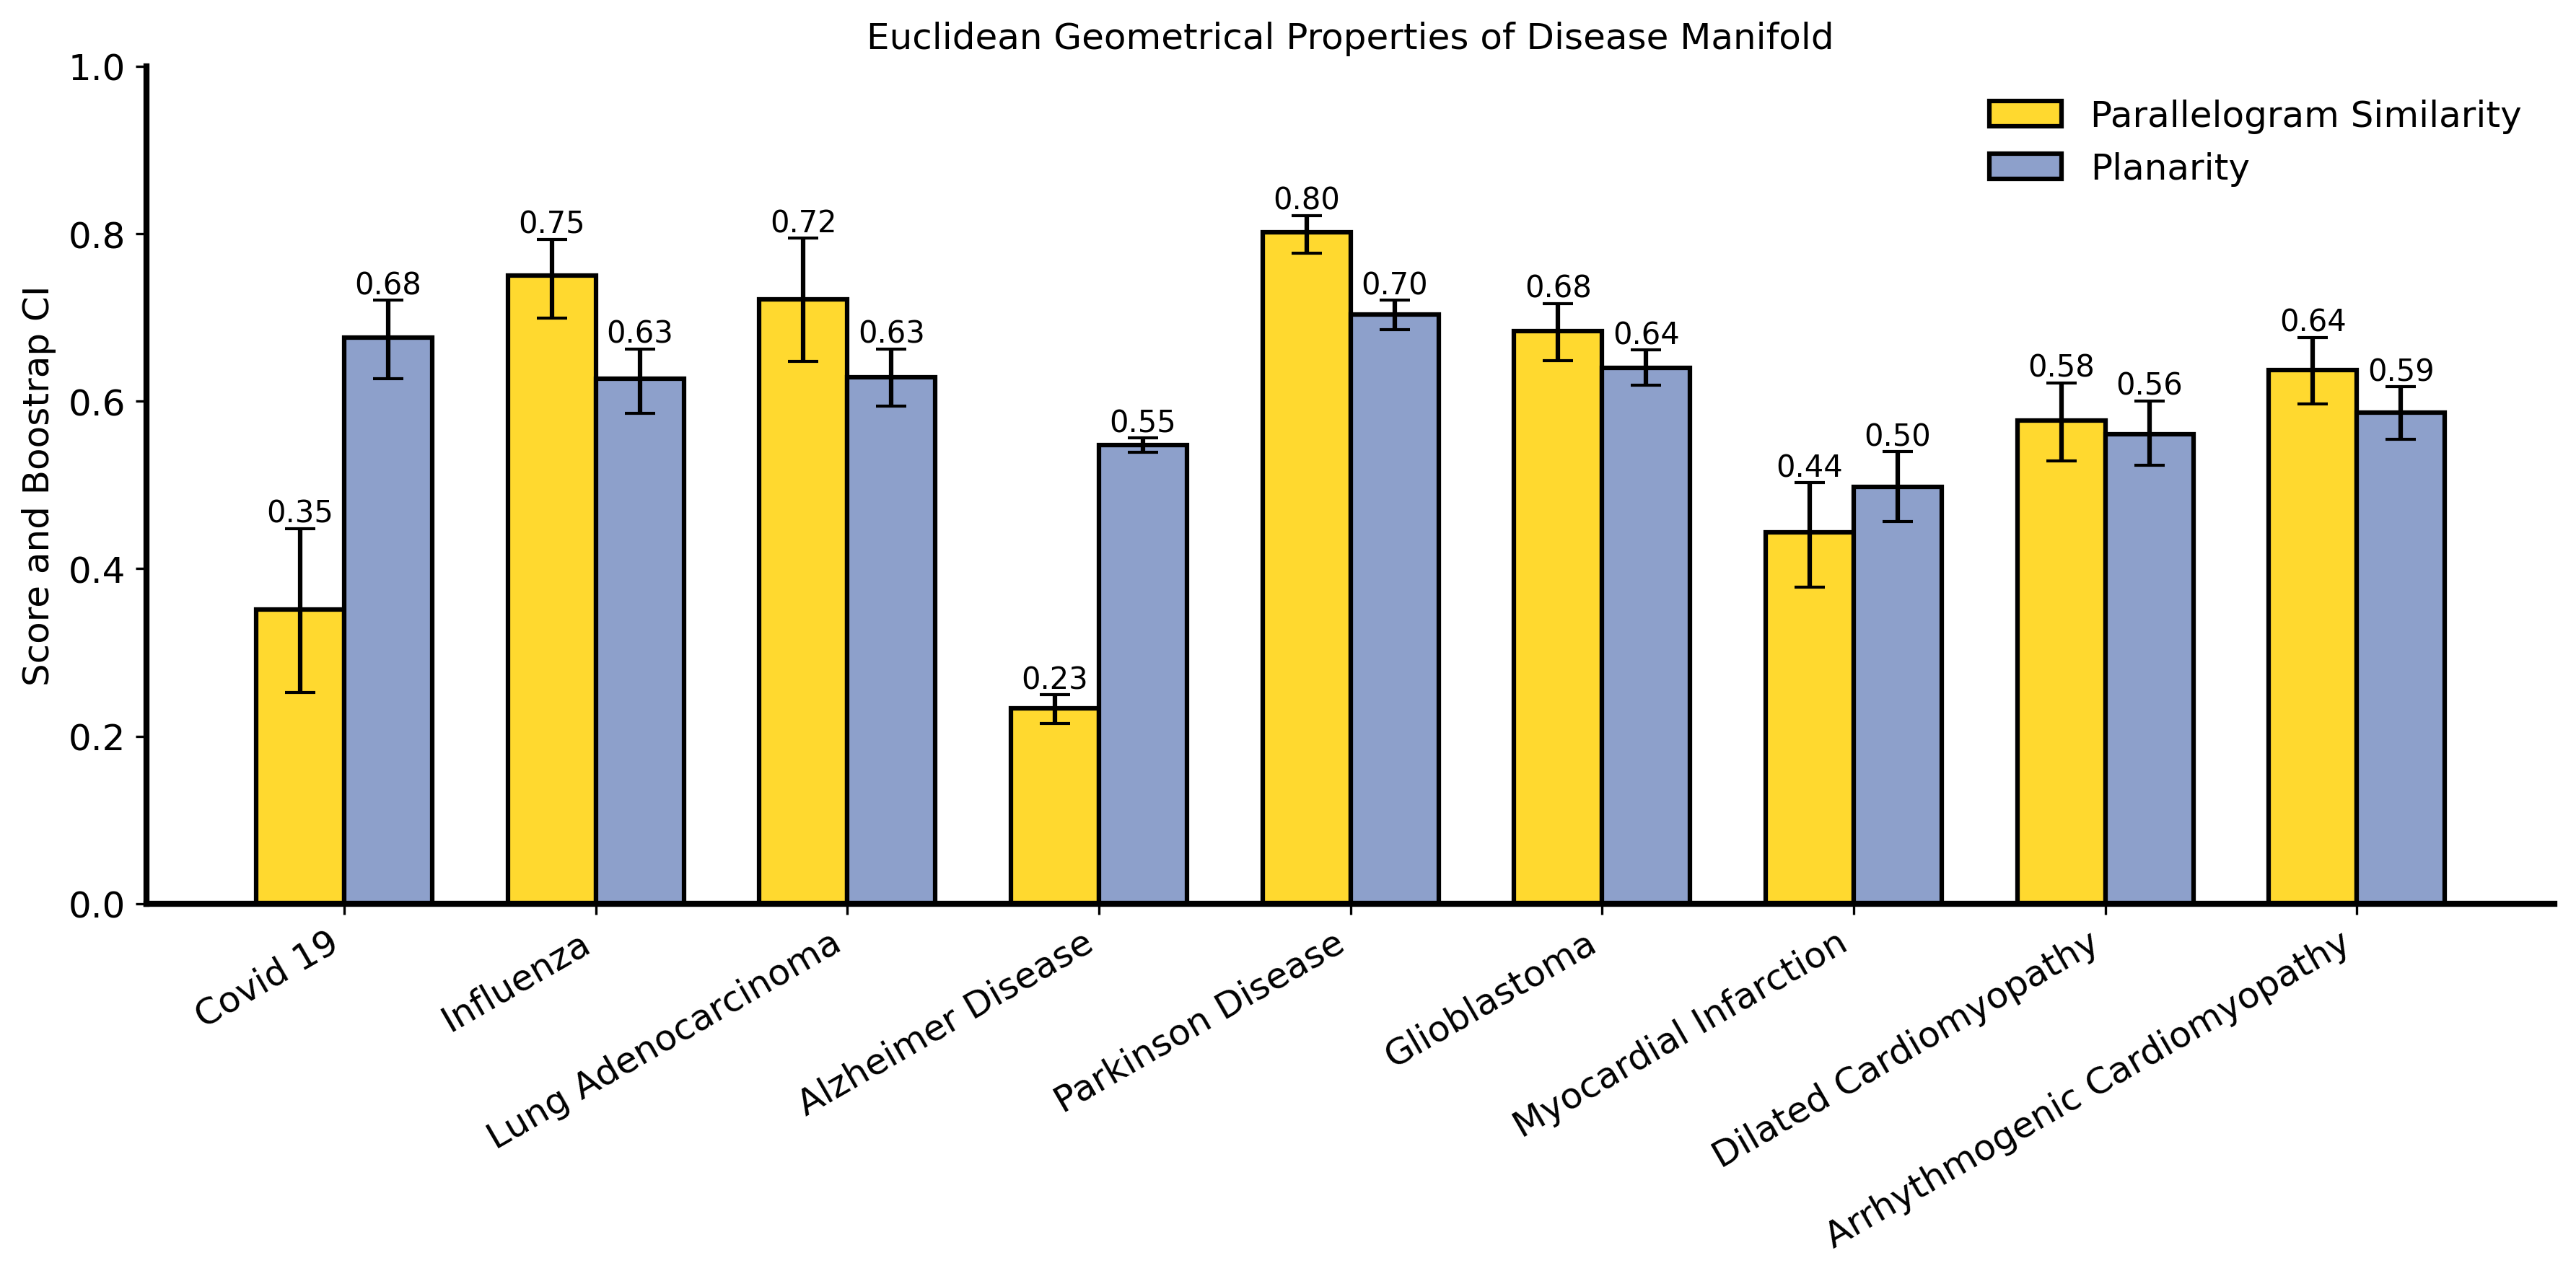

In [25]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
fontsize = 12
SAVE=True
def plot_scores(results_df, average_per_disease=False):
    metric_labels = {
    "parallelogram": r"Parallelogram Similarity",# = $\sqrt{(s_1)(s_2)}$",
    "planarity": r"Planarity",# = $\frac{1}{1+d/s}$",
    }
    long_df=results_df.stack(list(range(results_df.columns.nlevels))).reset_index(name='stats')
    long_df=pd.concat([long_df.drop(columns='stats'),pd.json_normalize(long_df['stats'])],axis=1).rename(columns={'level_0':'metric','level_1':'disease','level_2':'cell_a','level_3':'cell_b'})
    if average_per_disease:
        plot_df=long_df.groupby(['metric','disease'],as_index=False).agg(mean=('mean','mean'),ci_low=('ci_low','mean'),ci_high=('ci_high','mean'))
        plot_df['label']=plot_df['disease']
        desired_order = ["covid_19", "influenza", "lung_adenocarcinoma", "alzheimer_disease", "parkinson_disease", "glioblastoma", "myocardial_infarction", "dilated_cardiomyopathy", "arrhythmogenic_right_ventricular_cardiomyopathy"]
        plot_df['disease_order'] = pd.Categorical(plot_df['disease'], categories=desired_order, ordered=True).codes
        plot_df = plot_df.sort_values('disease_order')
    else:
        long_df['label']=long_df['disease']+'_'+long_df['cell_a']+'_'+long_df['cell_b']
        plot_df=long_df[['metric','label','mean','ci_low','ci_high']]
    plt.figure(figsize=(12,6),dpi=300 if SAVE else 300)
    ax=plt.gca();width=0.35;x=np.arange(plot_df['label'].nunique());palette=sns.color_palette('Set2_r',2)
    for i,m in enumerate(plot_df['metric'].unique()):
        subset=plot_df[plot_df['metric']==m]
        yerr=np.vstack([subset['mean']-subset['ci_low'],subset['ci_high']-subset['mean']])
        bars=ax.bar(x+i*width,subset['mean'],width=width,yerr=yerr,capsize=5,label=metric_labels[m],color=palette[i],edgecolor='k',lw=1.5)
        for idx, (bar,val) in enumerate(zip(bars,subset['mean']), start=0):
            ax.text(bar.get_x()+bar.get_width()/2,val + yerr[1, idx] ,
                    f"{val:.2f}",ha='center',va='bottom',fontsize=fontsize-2) 
    ax.set_ylim(0,1)
    ax.set_xticks(x+width/2)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_linewidth(2)
    
    labels = [label.replace('Arrhythmogenic Right Ventricular', 'Arrhythmogenic') for label in plot_df['label'].drop_duplicates().str.replace('_',' ').str.title()]
    #print(plot_df)
    ax.set_xticklabels(labels,rotation=30,ha='right', fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    ax.legend(edgecolor='k', loc="upper right", fontsize=fontsize, frameon=False)
    ax.set_title("Euclidean Geometrical Properties of Disease Manifold")
    ax.set_ylabel('Score and Boostrap CI', fontsize=fontsize)
    plt.tight_layout()
    #if SAVE: plt.savefig('../figures/figure4/euclidean_properties.svg', dpi=300, transparent=True)
    if SAVE: plt.savefig('../figures/figure4/show/euclidean_properties.png', dpi=300, transparent=False)
    plt.show()

plot_scores(pd.DataFrame(results), average_per_disease=True)

#### This is a strong motivation that shows the power of tangent map analogy and analogical reasoning but also shows it is not the full picture and this manifold is a curved manifold with complex topology.

## Attributions


- Here we should that our latent space models the progression of disease from healthy in 2 ways:
    1. We show the attributions of specific phenotypes yield greater results than their linear baselines
    2. We should the quality of these feature attributions is correlated to the disease vector

We visualize (1) with PR curves and insertion/deletion curves. And (2) with the overlap versus the coordinates of cells w.r.t to the disease vector. 

We also report the table of attributions overlap per method used.
 

In [ ]:
import sys
from tqdm import tqdm
sys.path.append('../../../')
import scanpy as sc
from polygene.model.model import load_trained_model
import numpy as np, pandas as pd
from rapidfuzz import process, fuzz
from polygene.analysis.attributions import AttributionAnalysis
from polygene.analysis.notebooks.get_disease_vectors import compute_disease_vectors
EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_vector/vector_data/'
model_path = "../../../runs/gesam_polygene_run_4/" #'/media/lleger/LaCie/mit/disease_vector/POLYGENE/' #

m, tok = load_trained_model(model_path)
tok.bypass_inference=True
phenotypic_types = tok.phenotypic_types
DISEASES_DICT = {'respiratory': ['COVID-19','influenza','lung adenocarcinoma'],
                 'neurological': ['Alzheimer disease','Parkinson disease','glioblastoma'],
                 'cardiometabolic': ['myocardial infarction','dilated cardiomyopathy','arrhythmogenic right ventricular cardiomyopathy']}
disease_list = sum(list(DISEASES_DICT.values()), [])
results={}
dv_genes = None
pbar = tqdm(disease_list)
num_cells = 100
num_opentarget_genes = 50
METHOD = "IQR"
for disease in pbar:
    pbar.set_description(f"Disease Vectors {disease}")
    cells = sc.read_h5ad(f"{EMBEDDINGS_DIR}{disease}_cells.h5ad")
    cells.obs_names_make_unique()
    normal_cells = cells[cells.obs['disease'] == 'normal'][:num_cells]
    disease_cells = cells[cells.obs['disease'] == disease][:num_cells]

    analyzer = AttributionAnalysis(m, tok, data=sc.concat([normal_cells, disease_cells]),
                                    biotype_json="../../data_utils/vocab/gene_biotypes.json", ensembl_json="../../data_utils/vocab/ensembl_to_gene.json")

    opentarget_genes = analyzer.get_associated_genes(disease, disease_cells.obs['disease_ontology_term_id'].tolist()[0], top=num_opentarget_genes)
    if not opentarget_genes: continue

    out_gwas, out_mi = analyzer.baselines(phenotype_obs_key='disease', case_label=disease_cells.obs['disease'].unique()[0], control_label="normal", k=num_opentarget_genes, method_top_attr=METHOD, start_with_X=int(1e4))

    #dv_genes = analyzer.disease_vector_ig(index_pairs=list(zip(normal_cells.obs_names.tolist(), disease_cells.obs_names.tolist())), only_protein_encoding=True, disable_pbar=True, steps=2).sum(axis=0)
    #out_dv = analyzer.validate_attributions(k=num_opentarget_genes, method_top_attr=METHOD, phenotype_obs_value=disease_cells.obs['disease'].unique()[0], baseline=dv_genes)
    
    analyzer.data = disease_cells
    grad_genes = analyzer.gradients(only_protein_encoding=True, disable_pbar=True).sum(axis=0)
    out_grad = analyzer.validate_attributions(k=num_opentarget_genes, method_top_attr=METHOD, phenotype_obs_value=disease_cells.obs['disease'].unique()[0], baseline=grad_genes)

    ig_genes = analyzer.integrated_gradients(only_protein_encoding=True, steps=2, disable_pbar=True).sum(axis=0)
    out_ig = analyzer.validate_attributions(k=num_opentarget_genes, method_top_attr=METHOD, phenotype_obs_value=disease_cells.obs['disease'].unique()[0], baseline=ig_genes)
    dl_genes = analyzer.deep_lift(only_protein_encoding=True, disable_pbar=True).sum(axis=0)
    out_dl = analyzer.validate_attributions(k=num_opentarget_genes, method_top_attr=METHOD, phenotype_obs_value=disease_cells.obs['disease'].unique()[0], baseline=dl_genes)
    results[disease] = {"GWAS": out_gwas, "Mutual Information": out_mi, 
                            #"Disease Vector": out_dv,
                            "Gradients": out_grad,
                            "Integrated Gradients": out_ig, "DeepLIFT": out_dl,
                            "OpenTargets":(set(list(opentarget_genes.keys())), pd.Series(opentarget_genes), 1, 1, 1, 0, (set(list(opentarget_genes.keys()))))}

pd.to_pickle(results, EMBEDDINGS_DIR + f'attribution_results.pkl')

Disease Vectors COVID-19:   0%|          | 0/9 [00:00<?, ?it/s]/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
Disease Vectors influenza:  11%|█         | 1/9 [00:29<03:57, 29.63s/it]/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
Disease Vectors lung adenocarcinoma:  22%|██▏       | 2/9 [01:05<03:54, 33.49s/it]/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear


In [11]:
import sys
from tqdm import tqdm
sys.path.append('../../../')
import scanpy as sc
from polygene.model.model import load_trained_model
import matplotlib.pyplot as plt, seaborn as sns, numpy as np, pandas as pd


#def recall()

def visualize_attributions(path_to_results = EMBEDDINGS_DIR + f'attribution_results.pkl'):
    df = pd.DataFrame(pd.read_pickle(path_to_results))
    display(df.applymap(lambda x: x[2]))

visualize_attributions()

,COVID-19,influenza,lung adenocarcinoma,Alzheimer disease,Parkinson disease,glioblastoma,myocardial infarction,dilated cardiomyopathy,arrhythmogenic right ventricular cardiomyopathy
GWAS,0.115385,0.066667,0.000000,0.160000,0.125000,0.296296,0.00000,0.000000,0.000000
Mutual Information,0.214286,0.062500,0.038462,0.120000,0.173913,0.176471,0.08000,0.095238,0.111111
Gradients,0.257143,0.117647,0.200000,0.236842,0.222222,0.302326,0.28125,0.135135,0.553191
Integrated Gradients,0.257143,0.117647,0.200000,0.236842,0.222222,0.302326,0.28125,0.135135,0.531915
DeepLIFT,0.257143,0.117647,0.150000,0.236842,0.222222,0.302326,0.18750,0.162162,0.574468
OpenTargets,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [18]:
result = (
    attribution_benchmark.applymap(lambda x: x[0])
    .groupby(attribution_benchmark.columns.to_series().apply(lambda x: x.split(' ')[0]), axis=1)
    .mean()
)
result

,alzheimer_disease,arrhythmogenic_right_ventricular_cardiomyopathy,covid_19,dilated_cardiomyopathy,glioblastoma,influenza,lung_adenocarcinoma,myocardial_infarction,parkinson_disease
GWAS,0.220,0.120000,0.1550,0.153333,0.286667,0.080,0.066667,0.133333,0.176
Mutual Information,0.290,0.283333,0.1825,0.110000,0.266667,0.060,0.083333,0.116667,0.156
Disease Vector,0.235,0.386667,0.2400,0.216667,0.400000,0.040,0.066667,0.233333,0.216
Gradients,0.290,0.383333,0.2425,0.223333,0.420000,0.045,0.070000,0.230000,0.218
Integrated Gradients,0.285,0.370000,0.2475,0.213333,0.410000,0.070,0.056667,0.220000,0.210
DeepLIFT,0.275,0.380000,0.2350,0.220000,0.430000,0.045,0.070000,0.230000,0.202


In [27]:
def analyze_benchmark(df, k=25, method_top_attr="IQR"):
    def recall(y, y_pred):
        y_pred = y_pred[:int(1e4)]
        y = set(list(y)[:k])
        if len(y_pred.shape) > 1: return 0
        q1, q3 = y_pred.quantile([0.25, 0.75])
        iqr = q3 - q1
        threshold = q3 #+ 1.5 * iqr
        y_pred_tp = set(y_pred[y_pred > threshold].index.tolist())
        TP = len(y & y_pred_tp)
        max_overlap = len(y & set(y_pred.index.tolist()))
        return TP / max_overlap
    
    return df.applymap(lambda x: recall(x[4], x[5]))

analyze_benchmark(attribution_benchmark)

,covid_19 cd8_positive_alpha_beta_t_cell,covid_19 classical_monocyte,covid_19 cd4_positive_alpha_beta_t_cell,covid_19 b_cell,influenza classical_monocyte,influenza cd8_positive_alpha_beta_t_cell,lung_adenocarcinoma b_cell,lung_adenocarcinoma cd4_positive_alpha_beta_t_cell,lung_adenocarcinoma cd8_positive_alpha_beta_t_cell,alzheimer_disease microglial_cell,...,glioblastoma microglial_cell,myocardial_infarction cardiac_muscle_myoblast,myocardial_infarction cardiac_endothelial_cell,myocardial_infarction fibroblast_of_cardiac_tissue,dilated_cardiomyopathy cardiac_muscle_cell,dilated_cardiomyopathy fibroblast_of_cardiac_tissue,dilated_cardiomyopathy endothelial_cell,arrhythmogenic_right_ventricular_cardiomyopathy endothelial_cell,arrhythmogenic_right_ventricular_cardiomyopathy cardiac_muscle_cell,arrhythmogenic_right_ventricular_cardiomyopathy fibroblast_of_cardiac_tissue
GWAS,0.363636,0.153846,0.200000,0.285714,0.222222,0.111111,0.000000,0.181818,0.363636,0.181818,...,0.500000,0.181818,0.230769,0.333333,0.357143,0.200000,0.333333,0.357143,0.272727,0.500000
Mutual Information,0.166667,0.384615,0.285714,0.312500,0.100000,0.090909,0.625000,0.272727,0.200000,0.384615,...,0.461538,0.307692,0.250000,0.500000,0.300000,0.142857,0.416667,0.153846,0.500000,0.312500
Disease Vector,0.176471,0.333333,0.277778,0.350000,0.090909,0.125000,0.333333,0.100000,0.125000,0.058824,...,0.444444,0.200000,0.400000,0.466667,0.466667,0.428571,0.266667,0.470588,0.722222,0.615385
Gradients,0.250000,0.411765,0.277778,0.300000,0.090909,0.125000,0.272727,0.100000,0.125000,0.277778,...,0.611111,0.357143,0.461538,0.500000,0.428571,0.400000,0.266667,0.588235,0.800000,0.461538
Integrated Gradients,0.250000,0.411765,0.333333,0.350000,0.181818,0.250000,0.181818,0.100000,0.125000,0.333333,...,0.611111,0.428571,0.461538,0.571429,0.500000,0.466667,0.266667,0.411765,0.733333,0.461538
DeepLIFT,0.312500,0.411765,0.277778,0.350000,0.090909,0.125000,0.272727,0.100000,0.125000,0.277778,...,0.611111,0.357143,0.461538,0.428571,0.428571,0.400000,0.266667,0.588235,0.800000,0.538462


In [60]:
import requests

def mondo_to_efo(mondo_id):
    url = f"https://www.ebi.ac.uk/spot/oxo/api/mappings?fromId={mondo_id}&size=1000"
    response = requests.get(url).json()
    efo_ids = []
    for mapping in response.get("_embedded", {}).get("mappings", []):
        curie = mapping.get("toTerm", {}).get("curie", "")
        if curie.startswith("EFO:"):
            efo_ids.append(curie)
    return list(set(efo_ids))

# Example:
print(mondo_to_efo("MONDO:0005148"))

['EFO:0001360']


In [59]:
from pronto import Ontology
mondo = Ontology("mondo.owl")
term = mondo["MONDO:0005148"]
efo_xrefs = [x.id for x in term.xrefs if x.id.startswith("EFO:")]

ValueError: unknown url type: 'mondo.owl'

In [58]:
import requests
def mondo_to_efo(mondo_id):
    mondo_iri = f"http://purl.obolibrary.org/obo/{mondo_id.replace(':', '_')}"
    url = f"https://www.ebi.ac.uk/ols4/api/ontologies/mondo/terms?iri={mondo_iri}"
    response = requests.get(url).json()
    efo_xrefs = []
    for term in response.get('_embedded', {}).get('terms', []):
        for xref in term.get('obo_xrefs', []):
            if xref.get('database') == 'EFO':
                efo_xrefs.append(xref['id'])
    return list(set(efo_xrefs))
mondo_to_efo("MONDO_0005068")

[]

In [56]:
sc.read_h5ad(EMBEDDINGS_DIR + "Parkinson disease_cells.h5ad").obs.value_counts(subset=['disease', 'disease_ontology_term_id'])
sc.read_h5ad(EMBEDDINGS_DIR + "myocardial infarction_cells.h5ad").obs.value_counts(subset=['disease', 'disease_ontology_term_id'])

disease                disease_ontology_term_id
myocardial infarction  MONDO:0005068               6000
normal                 PATO:0000461                6000
dtype: int64

In [2]:
attribution_benchmark.applymap(lambda x: x[0]/x[-1])

,covid_19 cd8_positive_alpha_beta_t_cell,covid_19 classical_monocyte,covid_19 cd4_positive_alpha_beta_t_cell,covid_19 b_cell,alzheimer_disease microglial_cell,alzheimer_disease neuron,parkinson_disease endothelial_cell,parkinson_disease oligodendrocyte,parkinson_disease microglial_cell,parkinson_disease astrocyte,parkinson_disease neuron,glioblastoma oligodendrocyte,glioblastoma endothelial_cell,glioblastoma microglial_cell,arrhythmogenic_right_ventricular_cardiomyopathy endothelial_cell,arrhythmogenic_right_ventricular_cardiomyopathy cardiac_muscle_cell,arrhythmogenic_right_ventricular_cardiomyopathy fibroblast_of_cardiac_tissue
GWAS,0.56,0.47,0.47,0.45,0.40,0.42,0.48,0.46,0.48,0.50,0.42,0.69,0.61,0.51,0.45,0.39,0.14
Mutual Information,0.56,0.54,0.47,0.45,0.62,0.58,0.60,0.51,0.53,0.49,0.50,0.58,0.75,0.57,0.64,0.67,0.66
Disease Vector,0.69,0.73,0.65,0.73,0.98,0.89,0.88,0.90,0.90,0.89,0.88,0.87,0.88,0.93,0.83,0.86,0.87
Gradients,0.78,0.72,0.62,0.77,0.88,0.89,0.89,0.88,0.88,0.87,0.88,0.93,0.95,0.91,0.79,0.88,0.83
Integrated Gradients,0.78,0.72,0.62,0.77,0.88,0.89,0.89,0.88,0.88,0.87,0.88,0.93,0.95,0.91,0.79,0.88,0.83
DeepLIFT,0.78,0.72,0.62,0.77,0.88,0.89,0.89,0.88,0.88,0.87,0.88,0.93,0.95,0.91,0.79,0.88,0.83


In [22]:
attribution_benchmark.applymap(lambda x: len(x[5]))


,covid_19 cd8_positive_alpha_beta_t_cell,covid_19 classical_monocyte,covid_19 cd4_positive_alpha_beta_t_cell,covid_19 b_cell,alzheimer_disease microglial_cell,alzheimer_disease neuron,parkinson_disease endothelial_cell,parkinson_disease oligodendrocyte,parkinson_disease microglial_cell,parkinson_disease astrocyte,parkinson_disease neuron,glioblastoma oligodendrocyte,glioblastoma endothelial_cell,glioblastoma microglial_cell,arrhythmogenic_right_ventricular_cardiomyopathy endothelial_cell,arrhythmogenic_right_ventricular_cardiomyopathy cardiac_muscle_cell,arrhythmogenic_right_ventricular_cardiomyopathy fibroblast_of_cardiac_tissue
GWAS,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
Mutual Information,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
Disease Vector,12457,11679,11951,12482,15386,14272,14767,14737,15384,14943,14188,14816,14763,15304,13762,14708,15281
Gradients,13619,11823,11633,13196,12789,14787,14450,14109,14261,14209,13594,14492,14256,13517,13954,14611,14453
Integrated Gradients,13619,11823,11633,13196,12789,14787,14450,14109,14261,14209,13594,14492,14256,13517,13954,14611,14453
DeepLIFT,13619,11823,11633,13196,12789,14787,14450,14109,14261,14209,13594,14492,14256,13517,13954,14611,14453


In [17]:

result = (
    attribution_benchmark.applymap(lambda x: x[-1])
    .groupby(attribution_benchmark.columns.to_series().apply(lambda x: x.split(' ')[0]), axis=1)
    .mean()
)
display(result)
result.columns = pd.Series(result.columns.tolist()).apply(lambda x: ' '.join(x.split('_')).title())# to_series().apply(lambda: x: ' '.join(x.spit('_')).title())
print(result.round(3).to_latex(column_format = "l" + "c"*len(result.columns), index=True, escape=False, bold_rows=False))

,alzheimer_disease,arrhythmogenic_right_ventricular_cardiomyopathy,covid_19,dilated_cardiomyopathy,glioblastoma,influenza,lung_adenocarcinoma,myocardial_infarction,parkinson_disease
GWAS,0.604978,0.413743,0.518295,0.469206,0.625672,0.369925,0.372936,0.516399,0.431035
Mutual Information,0.592065,0.515289,0.410616,0.243770,0.523291,0.218434,0.165621,0.365074,0.315905
Disease Vector,0.252941,0.523296,0.332434,0.301627,0.434338,0.113171,0.140397,0.350946,0.209134
Gradients,0.270588,0.509518,0.324675,0.259207,0.450231,0.113171,0.105225,0.298666,0.225674
Integrated Gradients,0.305882,0.512016,0.369468,0.316270,0.454269,0.153453,0.105225,0.314075,0.239225
DeepLIFT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


\begin{tabular}{lccccccccc}
\toprule
{} &  Alzheimer Disease &  Arrhythmogenic Right Ventricular Cardiomyopathy &  Covid 19 &  Dilated Cardiomyopathy &  Glioblastoma &  Influenza &  Lung Adenocarcinoma &  Myocardial Infarction &  Parkinson Disease \\
\midrule
GWAS                 &              0.605 &                                            0.414 &     0.518 &                   0.469 &         0.626 &      0.370 &                0.373 &                  0.516 &              0.431 \\
Mutual Information   &              0.592 &                                            0.515 &     0.411 &                   0.244 &         0.523 &      0.218 &                0.166 &                  0.365 &              0.316 \\
Disease Vector       &              0.253 &                                            0.523 &     0.332 &                   0.302 &         0.434 &      0.113 &                0.140 &                  0.351 &              0.209 \\
Gradients            &              0.271 & 

/tmp/ipykernel_2047399/2144451240.py:8: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(result.round(3).to_latex(column_format = "l" + "c"*len(result.columns), index=True, escape=False, bold_rows=False))


In [49]:

result = (
    attribution_benchmark.applymap(lambda x: x[0] / x[-1])
    .groupby(attribution_benchmark.columns.to_series().apply(lambda x: x.split(' ')[0]), axis=1)
    .mean()
)
result.columns = pd.Series(result.columns.tolist()).apply(lambda x: ' '.join(x.split('_')).title())# to_series().apply(lambda: x: ' '.join(x.spit('_')).title())
print(result.round(3).to_latex(column_format = "l" + "c"*len(result.columns), index=True, escape=False, bold_rows=False))

\begin{tabular}{lccccc}
\toprule
{} &  Alzheimer Disease &  Arrhythmogenic Right Ventricular Cardiomyopathy &  Covid 19 &  Glioblastoma &  Parkinson Disease \\
\midrule
GWAS                 &              0.410 &                                            0.327 &     0.488 &         0.603 &              0.468 \\
Mutual Information   &              0.600 &                                            0.657 &     0.505 &         0.633 &              0.526 \\
Disease Vector       &              0.935 &                                            0.853 &     0.700 &         0.893 &              0.890 \\
Gradients            &              0.885 &                                            0.833 &     0.722 &         0.930 &              0.880 \\
Integrated Gradients &              0.885 &                                            0.833 &     0.722 &         0.930 &              0.880 \\
DeepLIFT             &              0.885 &                                            0.833 &     0.722 &

/tmp/ipykernel_2037908/1892118930.py:7: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(result.round(3).to_latex(column_format = "l" + "c"*len(result.columns), index=True, escape=False, bold_rows=False))


In [6]:
attribution_benchmark.iloc[0, 0][-1]

0.4642857142857143

In [3]:
attribution_benchmark.applymap(lambda x: x[0]).mean(axis=1)

GWAS                    0.195294
Mutual Information      0.258824
Disease Vector          0.343529
Gradients               0.365882
Integrated Gradients    0.344706
DeepLIFT                0.362353
dtype: float64

In [45]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

for col in attribution_benchmark.columns:
    for i, method in enumerate(attribution_benchmark.index):
        entry = attribution_benchmark.loc[method, col]
        opentarget_genes, attributed_genes = set(entry[4]), set(entry[5].index.tolist())
        overlap = opentarget_genes & attributed_genes
        print(len(overlap)/len(opentarget_genes))
        break

0.4
0.56
0.5
0.42
0.52
0.5
0.58
0.42
0.6
0.54
0.5
0.6
0.58
0.48
0.62
0.56
0.18


In [ ]:
import matplotlib.pyplot as plt, seaborn as sns, numpy as np, pandas as pd
sys.path.append('../../../')
from polygene.model.model import load_trained_model
m, tok = load_trained_model("../../../runs/gesam_polygene_run_4/")
from polygene.analysis.attributions import AttributionAnalysis

tok.bypass_inference = True
attr_analyzer = AttributionAnalysis(m, tok, data=cells_label[endotype], biotype_json= "../data_utils/vocab/gene_biotypes.json",
                                    ensembl_json="../data_utils/vocab/ensembl_to_gene.json" )
attributed_genes = attr_analyzer.gradients(only_protein_encoding=True, disable_tqdm=True).sum(axis=0).sort_values(ascending=False).index.tolist()[:2]

## think about shooting geodesic flows, reversible paths